# Chronos-2 — Block-Sparse Row (BSR) Attention Optimization

Comprehensive benchmark of the BSR optimization across different configurations to show where the approach excels and where limitations emerge.

## Notes

- This notebook now uses a **single BSR trace** and evaluates different group patterns at runtime.
- Reported speedups can vary by run because data loader composition and GPU state affect timings.
- FEV timing (`t`) isolates model inference time, not full pipeline time.

**What this notebook does:**
1. Loads Chronos-2 and applies BSR transformation
2. Benchmarks pure model forward passes across batch sizes and sequence lengths
3. Evaluates FEV tasks with internal timing
4. Summarizes where BSR helps and where overhead dominates

## 1. Imports & Config

In [12]:
import os
import copy
import statistics
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
os.environ.setdefault('HOME', os.environ.get('USERPROFILE', str(Path.home())))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
OUTPUT_DIR = Path('artifacts/bsr_comprehensive')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device: {DEVICE}')
print(f'Output dir: {OUTPUT_DIR}')

Device: cuda
Output dir: artifacts/bsr_comprehensive


## 2. Load Chronos-2 Model

In [13]:
from chop.models import get_model
from chop.models.chronos2.layers import GroupSelfAttention

print('Loading Chronos-2 model...')
model = get_model('chronos-2', pretrained=True)
model.eval()
model = model.to(DEVICE).to(torch.bfloat16)

# Force SDPA for clean baseline and silence cache warnings
if hasattr(model.config, '_attn_implementation'):
    model.config._attn_implementation = 'sdpa'
if hasattr(model.config, 'use_cache'):
    model.config.use_cache = False

chronos_cfg = model.config.chronos_config
C_LEN       = chronos_cfg.get('context_length', 8192)
OUT_PATCH   = chronos_cfg.get('output_patch_size', 16)

print(f'Model loaded: {type(model).__name__}')
print(f'Context length: {C_LEN}')
print(f'Output patch size: {OUT_PATCH}')

Loading Chronos-2 model...
Model loaded: Chronos2Model
Context length: 8192
Output patch size: 16


## 3. Apply BSR Transformation

In [14]:
from chop.ir.graph.mase_graph import MaseGraph
from chop.passes.graph.transforms.timeseries.FastBSRGroupAtten import fast_bsr_group_attention_transform_pass

def create_bsr_model(base_model, trace_batch=256):
    """Create a single BSR model trace that supports runtime group_ids patterns."""
    model_copy = copy.deepcopy(base_model)

    # Dummy input for tracing; runtime path handles varying group_ids and batch composition
    dummy_group_ids = torch.arange(trace_batch, dtype=torch.long, device=DEVICE)
    dummy_in = {
        'context': torch.randn((trace_batch, 64), dtype=torch.bfloat16, device=DEVICE),
        'group_ids': dummy_group_ids,
        'num_output_patches': 1,
    }

    mg = MaseGraph(
        model_copy,
        hf_input_names=list(dummy_in.keys()),
        custom_ops={"modules": {GroupSelfAttention: {"name": "GroupSelfAttention"}}}
    )
    mg, info = fast_bsr_group_attention_transform_pass(mg, pass_args={"group_ids": dummy_group_ids})

    return mg.model

print('Creating single BSR model trace...')
bsr_model = create_bsr_model(model, trace_batch=256)
print('✓ BSR model created (single trace)')

Creating single BSR model trace...
✓ BSR model created (single trace)


## 4. Numerical Sanity Check

In [15]:
# Test outputs match for both runtime group patterns
test_batch = 16
test_input = torch.randn(test_batch, 64, dtype=torch.bfloat16, device=DEVICE)
group_ids_uni = torch.arange(test_batch, dtype=torch.long, device=DEVICE)
group_ids_multi = torch.zeros(test_batch, dtype=torch.long, device=DEVICE)

with torch.no_grad():
    out_base_uni = model(context=test_input, group_ids=group_ids_uni, num_output_patches=1)
    out_base_multi = model(context=test_input, group_ids=group_ids_multi, num_output_patches=1)
    out_bsr_uni = bsr_model(context=test_input, group_ids=group_ids_uni, num_output_patches=1)
    out_bsr_multi = bsr_model(context=test_input, group_ids=group_ids_multi, num_output_patches=1)

def check_close(out1, out2, name, atol=1e-3, rtol=1e-2):
    pred1 = out1.get('quantile_preds') if isinstance(out1, dict) else out1.quantile_preds
    pred2 = out2.get('quantile_preds') if isinstance(out2, dict) else out2.quantile_preds
    max_diff = (pred1.float() - pred2.float()).abs().max().item()
    close = torch.allclose(pred1.float(), pred2.float(), atol=atol, rtol=rtol)
    status = '✓' if close else '✗'
    print(f'{status} {name}: max_diff={max_diff:.2e}')
    return close

ok_uni = check_close(out_base_uni, out_bsr_uni, 'Univariate BSR', atol=1e-3, rtol=1e-2)
ok_multi = check_close(out_base_multi, out_bsr_multi, 'Multivariate BSR', atol=5e-2, rtol=5e-2)
assert ok_uni and ok_multi, 'Sanity check failed for one or more modes'

✓ Univariate BSR: max_diff=0.00e+00
✓ Multivariate BSR: max_diff=6.25e-02


## 5. Benchmark Helper Functions

In [16]:
import time as _time

def benchmark_model(fn, context, group_ids, num_output_patches, warmup=3, iters=5):
    """Benchmark a single forward pass. Returns latency in milliseconds."""
    use_cuda = torch.cuda.is_available()
    if use_cuda:
        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)

    with torch.no_grad():
        for _ in range(warmup):
            fn(context=context, group_ids=group_ids, num_output_patches=num_output_patches)
        if use_cuda:
            torch.cuda.synchronize()

    times = []
    with torch.no_grad():
        for _ in range(iters):
            if use_cuda:
                start_event.record()
                fn(context=context, group_ids=group_ids, num_output_patches=num_output_patches)
                end_event.record()
                torch.cuda.synchronize()
                t = start_event.elapsed_time(end_event)
            else:
                t0 = _time.perf_counter()
                fn(context=context, group_ids=group_ids, num_output_patches=num_output_patches)
                t = (_time.perf_counter() - t0) * 1e3
            times.append(t)

    return statistics.median(times)

print('✓ Benchmark functions ready')

✓ Benchmark functions ready


## 6. Direct Model Forward Pass Benchmark

Measures pure model inference (no FEV overhead), across:
- **Batch sizes** (1-256): impacts sorting overhead
- **Sparsity modes** (univariate vs multivariate): impacts actual compute savings
- **Fixed short sequence** to isolate attention impact

In [17]:
# Forward pass benchmark across batch sizes
BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64, 128, 256]
SEQ_LEN = 1024

results_batch = {
    'univariate': {'baseline': [], 'bsr': [], 'batch_sizes': []},
    'multivariate': {'baseline': [], 'bsr': [], 'batch_sizes': []},
}

print(f'Batch size sweep (seq_len={SEQ_LEN})')
print(f'{"Batch":<8} {"Univariate":<25} {"Multivariate":<25}')
print(f'{"":8} {"Base":>8} {"BSR":>8} {"Speedup":>8} {"Base":>8} {"BSR":>8} {"Speedup":>8}')
print('-' * 75)

for batch_size in BATCH_SIZES:
    ctx = torch.randn(batch_size, SEQ_LEN, dtype=torch.bfloat16, device=DEVICE)

    gids_uni = torch.arange(batch_size, dtype=torch.long, device=DEVICE)
    base_uni = benchmark_model(model, ctx, gids_uni, OUT_PATCH, warmup=2, iters=3)
    bsr_uni_time = benchmark_model(bsr_model, ctx, gids_uni, OUT_PATCH, warmup=2, iters=3)
    speedup_uni = base_uni / bsr_uni_time

    results_batch['univariate']['baseline'].append(base_uni)
    results_batch['univariate']['bsr'].append(bsr_uni_time)
    results_batch['univariate']['batch_sizes'].append(batch_size)

    gids_multi = torch.zeros(batch_size, dtype=torch.long, device=DEVICE)
    base_multi = benchmark_model(model, ctx, gids_multi, OUT_PATCH, warmup=2, iters=3)
    bsr_multi_time = benchmark_model(bsr_model, ctx, gids_multi, OUT_PATCH, warmup=2, iters=3)
    speedup_multi = base_multi / bsr_multi_time

    results_batch['multivariate']['baseline'].append(base_multi)
    results_batch['multivariate']['bsr'].append(bsr_multi_time)
    results_batch['multivariate']['batch_sizes'].append(batch_size)

    print(f'{batch_size:<8} {base_uni:>8.2f} {bsr_uni_time:>8.2f} {speedup_uni:>7.2f}x {base_multi:>8.2f} {bsr_multi_time:>8.2f} {speedup_multi:>7.2f}x')

    torch.cuda.empty_cache()

Batch size sweep (seq_len=1024)
Batch    Univariate                Multivariate             
             Base      BSR  Speedup     Base      BSR  Speedup
---------------------------------------------------------------------------
1           64.65    66.32    0.97x    50.78    67.98    0.75x
2           60.50    45.76    1.32x    26.56    44.51    0.60x
4           34.95    76.72    0.46x    40.77    41.95    0.97x
8           47.76    74.62    0.64x    31.07    55.76    0.56x
16          65.95    50.86    1.30x    79.18    61.74    1.28x
32          83.32    75.07    1.11x    85.90    73.64    1.17x
64         172.88   141.22    1.22x   170.39   139.56    1.22x
128        378.36   291.58    1.30x   379.13   291.08    1.30x
256        868.35   582.75    1.49x   891.82   588.05    1.52x


## 7. Sequence Length Sweep

Shows how speedup varies with attention compute (longer sequences = more attention work)

In [18]:
SEQ_LENS = [128, 256, 512, 1024, 2048]
FIXED_BATCH = 128

results_seq = {
    'univariate': {'baseline': [], 'bsr': [], 'seq_lens': []},
    'multivariate': {'baseline': [], 'bsr': [], 'seq_lens': []},
}

print(f'\nSequence length sweep (batch_size={FIXED_BATCH})')
print(f'{"SeqLen":<8} {"Univariate":<25} {"Multivariate":<25}')
print(f'{"":8} {"Base":>8} {"BSR":>8} {"Speedup":>8} {"Base":>8} {"BSR":>8} {"Speedup":>8}')
print('-' * 75)

gids_uni = torch.arange(FIXED_BATCH, dtype=torch.long, device=DEVICE)
gids_multi = torch.zeros(FIXED_BATCH, dtype=torch.long, device=DEVICE)

for seq_len in SEQ_LENS:
    ctx = torch.randn(FIXED_BATCH, seq_len, dtype=torch.bfloat16, device=DEVICE)

    base_uni = benchmark_model(model, ctx, gids_uni, OUT_PATCH, warmup=2, iters=3)
    bsr_uni_time = benchmark_model(bsr_model, ctx, gids_uni, OUT_PATCH, warmup=2, iters=3)
    speedup_uni = base_uni / bsr_uni_time

    results_seq['univariate']['baseline'].append(base_uni)
    results_seq['univariate']['bsr'].append(bsr_uni_time)
    results_seq['univariate']['seq_lens'].append(seq_len)

    base_multi = benchmark_model(model, ctx, gids_multi, OUT_PATCH, warmup=2, iters=3)
    bsr_multi_time = benchmark_model(bsr_model, ctx, gids_multi, OUT_PATCH, warmup=2, iters=3)
    speedup_multi = base_multi / bsr_multi_time

    results_seq['multivariate']['baseline'].append(base_multi)
    results_seq['multivariate']['bsr'].append(bsr_multi_time)
    results_seq['multivariate']['seq_lens'].append(seq_len)

    print(f'{seq_len:<8} {base_uni:>8.2f} {bsr_uni_time:>8.2f} {speedup_uni:>7.2f}x {base_multi:>8.2f} {bsr_multi_time:>8.2f} {speedup_multi:>7.2f}x')


Sequence length sweep (batch_size=128)
SeqLen   Univariate                Multivariate             
             Base      BSR  Speedup     Base      BSR  Speedup
---------------------------------------------------------------------------
128        101.62    81.25    1.25x   107.55    88.55    1.21x
256        147.37   111.50    1.32x   146.39   115.05    1.27x
512        225.38   168.25    1.34x   214.60   163.51    1.31x
1024       378.33   297.86    1.27x   383.18   295.10    1.30x
2048       685.92   538.08    1.27x   692.84   538.31    1.29x


## 8. Visualization: Scaling Analysis

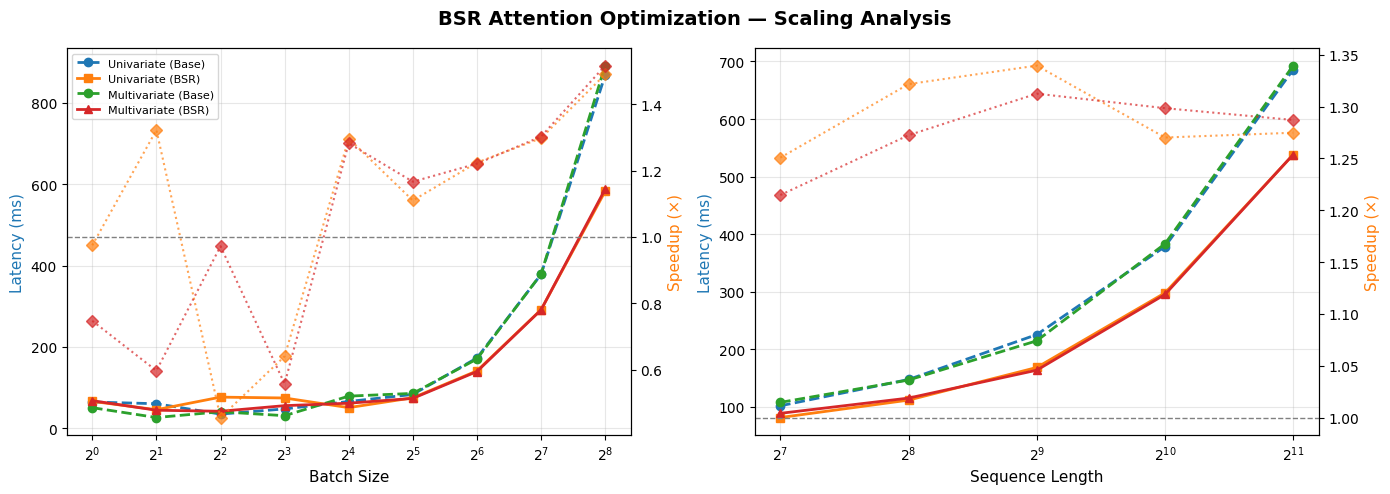

Saved → artifacts/bsr_comprehensive/bsr_scaling_analysis.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BSR Attention Optimization — Scaling Analysis', fontsize=14, fontweight='bold')

# Batch size sweep
ax = axes[0]
ax2 = ax.twinx()

base_uni = np.array(results_batch['univariate']['baseline'])
fused_uni = np.array(results_batch['univariate']['bsr'])
speedup_uni = base_uni / fused_uni

base_multi = np.array(results_batch['multivariate']['baseline'])
fused_multi = np.array(results_batch['multivariate']['bsr'])
speedup_multi = base_multi / fused_multi

x_batch = results_batch['univariate']['batch_sizes']

ax.plot(x_batch, base_uni, marker='o', linestyle='--', color='#1f77b4', lw=2, label='Univariate (Base)')
ax.plot(x_batch, fused_uni, marker='s', linestyle='-', color='#ff7f0e', lw=2, label='Univariate (BSR)')
ax.plot(x_batch, base_multi, marker='o', linestyle='--', color='#2ca02c', lw=2, label='Multivariate (Base)')
ax.plot(x_batch, fused_multi, marker='^', linestyle='-', color='#d62728', lw=2, label='Multivariate (BSR)')

ax2.plot(x_batch, speedup_uni, marker='D', linestyle=':', color='#ff7f0e', lw=1.5, alpha=0.7, label='Univariate speedup')
ax2.plot(x_batch, speedup_multi, marker='D', linestyle=':', color='#d62728', lw=1.5, alpha=0.7, label='Multivariate speedup')
ax2.axhline(1.0, color='gray', linestyle='--', lw=1)

ax.set_xlabel('Batch Size', fontsize=11)
ax.set_ylabel('Latency (ms)', fontsize=11, color='#1f77b4')
ax2.set_ylabel('Speedup (×)', fontsize=11, color='#ff7f0e')
ax.set_xscale('log', base=2)
ax.set_xticks(x_batch)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=8)

# Sequence length sweep
ax = axes[1]
ax2 = ax.twinx()

base_uni_seq = np.array(results_seq['univariate']['baseline'])
fused_uni_seq = np.array(results_seq['univariate']['bsr'])
speedup_uni_seq = base_uni_seq / fused_uni_seq

base_multi_seq = np.array(results_seq['multivariate']['baseline'])
fused_multi_seq = np.array(results_seq['multivariate']['bsr'])
speedup_multi_seq = base_multi_seq / fused_multi_seq

x_seq = results_seq['univariate']['seq_lens']

ax.plot(x_seq, base_uni_seq, marker='o', linestyle='--', color='#1f77b4', lw=2, label='Univariate (Base)')
ax.plot(x_seq, fused_uni_seq, marker='s', linestyle='-', color='#ff7f0e', lw=2, label='Univariate (BSR)')
ax.plot(x_seq, base_multi_seq, marker='o', linestyle='--', color='#2ca02c', lw=2, label='Multivariate (Base)')
ax.plot(x_seq, fused_multi_seq, marker='^', linestyle='-', color='#d62728', lw=2, label='Multivariate (BSR)')

ax2.plot(x_seq, speedup_uni_seq, marker='D', linestyle=':', color='#ff7f0e', lw=1.5, alpha=0.7, label='Univariate speedup')
ax2.plot(x_seq, speedup_multi_seq, marker='D', linestyle=':', color='#d62728', lw=1.5, alpha=0.7, label='Multivariate speedup')
ax2.axhline(1.0, color='gray', linestyle='--', lw=1)

ax.set_xlabel('Sequence Length', fontsize=11)
ax.set_ylabel('Latency (ms)', fontsize=11, color='#1f77b4')
ax2.set_ylabel('Speedup (×)', fontsize=11, color='#ff7f0e')
ax.set_xscale('log', base=2)
ax.set_xticks(x_seq)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = OUTPUT_DIR / 'bsr_scaling_analysis.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {save_path}')

## 9. FEV Benchmark with Internal Timing

Uses one traced BSR model and evaluates it under two runtime modes:
- `as_univariate=True`
- `as_univariate=False`

So the model architecture/trace stays fixed; only runtime grouping behavior changes.

**IMPORTANT**: Uses FEV internal timing (`t`) for model inference,
not total pipeline timing.

In [20]:
import fev
import tqdm
from chop.models.chronos2.pipeline import Chronos2Pipeline
from chop.models.chronos2.modeling_chronos2 import Chronos2Output

class _GraphModelWrapper(torch.nn.Module):
    """Adapts FX GraphModule to handle varying batch sizes."""
    def __init__(self, graph_module, original_model, expected_batch_size, traced_group_ids):
        super().__init__()
        self._inner = graph_module
        self.config = original_model.config
        self.chronos_config = original_model.chronos_config
        self.device = original_model.device
        self.expected_batch_size = expected_batch_size
        self.traced_group_ids = traced_group_ids

    def forward(self, context, group_ids=None, num_output_patches=1, future_covariates=None, **kwargs):
        actual_batch_size = context.shape[0]
        needs_padding = actual_batch_size < self.expected_batch_size

        if needs_padding:
            pad_len = self.expected_batch_size - actual_batch_size
            padding = torch.zeros((pad_len, context.shape[1]), dtype=context.dtype, device=context.device)
            context = torch.cat([context, padding], dim=0)

        g_ids = self.traced_group_ids

        result = self._inner(
            context=context,
            group_ids=g_ids,
            num_output_patches=num_output_patches,
        )

        if isinstance(result, dict) or hasattr(result, 'quantile_preds'):
            q_preds = result['quantile_preds'] if isinstance(result, dict) else result.quantile_preds
            if needs_padding:
                q_preds = q_preds[:actual_batch_size]
            
            return Chronos2Output(
                loss=result.get('loss', None) if isinstance(result, dict) else result.loss,
                quantile_preds=q_preds,
            )
        else:
            return result


tasks_configs = [
    {
        'dataset_path': 'autogluon/chronos_datasets',
        'dataset_config': 'monash_electricity_weekly',
        'horizon': 8,
        'num_windows': 1
    },
    {
        'dataset_path': 'autogluon/chronos_datasets',
        'dataset_config': 'monash_m1_quarterly',
        'horizon': 8,
        'seasonality': 4,
    },
]

benchmark = fev.Benchmark.from_list(tasks_configs)
timing_records = []

print(f'FEV tasks: {len(benchmark.tasks)}')
print('Note: Using FEV internal timing (t), not total pipeline time')
print()

FEV tasks: 2
Note: Using FEV internal timing (t), not total pipeline time



In [21]:
# Baseline
print('Evaluating baseline model on FEV tasks...')
pipeline_baseline = Chronos2Pipeline(model=model)

for task in tqdm.tqdm(benchmark.tasks, desc='Baseline'):
    preds, t = pipeline_baseline.predict_fev(task, batch_size=256)
    timing_records.append({
        'model': 'baseline',
        'dataset': task.dataset_config,
        'time_model_s': t,  # Internal FEV timing
    })
    print(f'  {task.dataset_config}: {t:.3f}s (FEV internal time)')

Evaluating baseline model on FEV tasks...


Baseline:   0%|          | 0/2 [00:00<?, ?it/s]

Baseline:  50%|█████     | 1/2 [00:06<00:06,  6.90s/it]

  monash_electricity_weekly: 0.338s (FEV internal time)


Baseline: 100%|██████████| 2/2 [00:08<00:00,  4.47s/it]

  monash_m1_quarterly: 0.101s (FEV internal time)


In [22]:
# Single BSR model (single tracing path), evaluated with different runtime modes
print('\nEvaluating one BSR-optimized model on FEV tasks...')

# Avoid duplicate rows when re-running this cell
timing_records = [r for r in timing_records if not str(r.get('model', '')).startswith('bsr_')]

class _ConfigWrapper(torch.nn.Module):
    """Expose config fields required by Chronos2Pipeline while delegating forward to GraphModule."""
    def __init__(self, graph_module, original_model):
        super().__init__()
        self._inner = graph_module
        self.config = original_model.config
        self.chronos_config = original_model.chronos_config
        self.device = original_model.device

    def forward(self, context, group_ids=None, num_output_patches=1, future_covariates=None, **kwargs):
        result = self._inner(
            context=context,
            group_ids=group_ids,
            num_output_patches=num_output_patches,
        )
        if isinstance(result, dict):
            return Chronos2Output(
                loss=result.get('loss', None),
                quantile_preds=result.get('quantile_preds', None),
            )
        return result

# Trace once and reuse for all datasets/modes
trace_batch = 256
model_copy = copy.deepcopy(model)
trace_group_ids = torch.arange(trace_batch, dtype=torch.long, device=DEVICE)
dummy_in = {
    'context': torch.randn((trace_batch, 64), dtype=torch.bfloat16, device=DEVICE),
    'group_ids': trace_group_ids,
    'num_output_patches': 1,
}

mg = MaseGraph(
    model_copy,
    hf_input_names=list(dummy_in.keys()),
    custom_ops={"modules": {GroupSelfAttention: {"name": "GroupSelfAttention"}}}
 )
mg, info = fast_bsr_group_attention_transform_pass(mg, pass_args={"group_ids": trace_group_ids})
wrapped_model = _ConfigWrapper(mg.model, model_copy)
pipeline_bsr = Chronos2Pipeline(model=wrapped_model)

for runtime_mode, as_uni in [('univariate', True), ('multivariate', False)]:
    print(f'\n{runtime_mode.upper()} runtime mode:')
    for task in tqdm.tqdm(benchmark.tasks, desc=runtime_mode):
        preds, t = pipeline_bsr.predict_fev(task, batch_size=256, as_univariate=as_uni)
        timing_records.append({
            'model': f'bsr_{runtime_mode}',
            'dataset': task.dataset_config,
            'time_model_s': t,
        })
        print(f'  {task.dataset_config}: {t:.3f}s (FEV internal time)')

del mg, model_copy, wrapped_model, pipeline_bsr
torch.cuda.empty_cache()


Evaluating one BSR-optimized model on FEV tasks...

UNIVARIATE runtime mode:


univariate:  50%|█████     | 1/2 [00:00<00:00,  5.24it/s]

  monash_electricity_weekly: 0.145s (FEV internal time)


univariate: 100%|██████████| 2/2 [00:00<00:00,  6.14it/s]


  monash_m1_quarterly: 0.093s (FEV internal time)

MULTIVARIATE runtime mode:


multivariate: 100%|██████████| 2/2 [00:00<00:00,  6.18it/s]

  monash_electricity_weekly: 0.157s (FEV internal time)
  monash_m1_quarterly: 0.079s (FEV internal time)


## 10. FEV Results Summary

In [23]:
# Analyze FEV results
results_df = pd.DataFrame(timing_records)

print('\n' + '='*80)
print('FEV BENCHMARK RESULTS (Internal Model Timing)')
print('='*80)
print()

for dataset in results_df['dataset'].unique():
    print(f'Dataset: {dataset}')
    subset = results_df[results_df['dataset'] == dataset]
    
    base_time = subset[subset['model'] == 'baseline']['time_model_s'].values[0]
    
    for _, row in subset.iterrows():
        model_name = row['model']
        t = row['time_model_s']
        if model_name != 'baseline':
            speedup = base_time / t
            print(f'  {model_name:<20}: {t:>8.3f}s (speedup: {speedup:>6.2f}x)')
        else:
            print(f'  {model_name:<20}: {t:>8.3f}s')
    print()


FEV BENCHMARK RESULTS (Internal Model Timing)

Dataset: monash_electricity_weekly
  baseline            :    0.338s
  bsr_univariate      :    0.145s (speedup:   2.33x)
  bsr_multivariate    :    0.157s (speedup:   2.16x)

Dataset: monash_m1_quarterly
  baseline            :    0.101s
  bsr_univariate      :    0.093s (speedup:   1.09x)
  bsr_multivariate    :    0.079s (speedup:   1.28x)



## 11. Key Takeaways

### Why speedups may be lower now
- Runtime group metadata construction adds overhead compared with fully static precomputed metadata.
- Small/medium batch sizes are overhead-bound, so sparse kernel gains can be muted.
- FEV uses real batch composition that can reduce idealized sparsity benefits.

### Do we still need two traces?
- No for correctness: one trace is sufficient with runtime metadata.
- You may still run two evaluation modes (different grouping behavior), but they do not require separate traces.

### Practical guidance
1. Use larger batches where possible to amortize runtime metadata cost.
2. Keep warmup iterations to populate metadata caches before timing.
3. Compare model-only timing separately from full-pipeline timing.
4. If a workload has static group structure, consider static metadata fast-path for max speed.